# Notebook 2 -- Semi-Supervised Learning

**Goal**: Use the 70 labeled images + 1,406 unlabeled images to build a classifier that outperforms a purely supervised approach. We test multiple semi-supervised strategies and compare them.

**Methods tested**:
1. Label Propagation / Label Spreading (graph-based)
2. Pseudo-labeling with confidence thresholds (iterative)
3. CNN with semi-supervised pre-training (two-phase transfer learning)

---

**Detailed pipeline**:
1. Load pre-computed ResNet-50 embeddings and weak labels from Notebook 1
2. Establish baselines (DummyClassifier, Logistic Regression on 70 labeled)
3. Semi-supervised on embeddings: Label Propagation, Pseudo-Labeling
4. CNN fine-tuning: supervised vs semi-supervised
5. Compare all models, bootstrap confidence intervals, scaling recommendations

**Dataset recap**: 50 normal + 50 cancer labeled MRI images (512x512 JPEG), 1,406 unlabeled. 70/30 stratified split on labeled data.

## 2.1 Setup & Data Loading

Import all dependencies, set reproducibility seeds, and load pre-computed embeddings and weak labels from Notebook 1. We recreate the exact same 70/30 stratified split using `random_state=42`.

In [1]:
import random, warnings
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import binomtest

# Reproducibility seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
DATA_DIR = Path("data")

print(f"Device: {DEVICE}")
print("All imports loaded. Seeds set to 42.")

Device: mps
All imports loaded. Seeds set to 42.


In [2]:
# Load pre-computed embeddings from Notebook 1
emb_data = np.load(DATA_DIR / "embeddings.npz", allow_pickle=True)
embeddings_all = emb_data["embeddings"]
all_labels = emb_data["labels"]
all_paths = list(emb_data["paths"])

# Load weak labels from Notebook 1
wl_data = np.load(DATA_DIR / "weak_labels.npz", allow_pickle=True)
weak_labels_all = wl_data["weak_labels"]

print(f"Embeddings: {embeddings_all.shape}")
print(f"Labels:     {all_labels.shape} — unique: {np.unique(all_labels)}")
print(f"Weak labels: {weak_labels_all.shape}")
print(f"Paths:      {len(all_paths)}")

Embeddings: (1506, 2048)
Labels:     (1506,) — unique: [-1  0  1]
Weak labels: (1506,)
Paths:      1506


In [3]:
# Separate labeled and unlabeled data (same logic as NB1)
labeled_mask = all_labels >= 0
unlabeled_mask = all_labels == -1

X_labeled = embeddings_all[labeled_mask]
y_labeled = all_labels[labeled_mask]
X_unlabeled = embeddings_all[unlabeled_mask]
paths_labeled = np.array(all_paths)[labeled_mask]
paths_unlabeled = np.array(all_paths)[unlabeled_mask]

# Recreate exact same 70/30 stratified split as NB1
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X_labeled, y_labeled, paths_labeled,
    test_size=0.30, stratify=y_labeled, random_state=SEED,
)

print(f"Train: {X_train.shape} — Normal: {(y_train==0).sum()}, Cancer: {(y_train==1).sum()}")
print(f"Test:  {X_test.shape}  — Normal: {(y_test==0).sum()}, Cancer: {(y_test==1).sum()}")
print(f"Unlabeled: {X_unlabeled.shape}")
print(f"\n{'='*50}")
print("TEST SET IS SEALED — used for final evaluation only.")
print(f"{'='*50}")

Train: (70, 2048) — Normal: 35, Cancer: 35
Test:  (30, 2048)  — Normal: 15, Cancer: 15
Unlabeled: (1406, 2048)

TEST SET IS SEALED — used for final evaluation only.


In [4]:
# Fit StandardScaler on TRAIN set only (same as NB1 for consistency)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_unlabeled_scaled = scaler.transform(X_unlabeled)

print(f"Scaler fitted on {X_train_scaled.shape[0]} training samples.")
print(f"X_train_scaled: {X_train_scaled.shape}, mean~{X_train_scaled.mean():.4f}, std~{X_train_scaled.std():.4f}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print(f"X_unlabeled_scaled: {X_unlabeled_scaled.shape}")

Scaler fitted on 70 training samples.
X_train_scaled: (70, 2048), mean~0.0000, std~0.9983
X_test_scaled:  (30, 2048)
X_unlabeled_scaled: (1406, 2048)


In [5]:
# Extract weak labels for unlabeled images (matching NB1 order)
# weak_labels_all is indexed by position in the full dataset
weak_labels_unlabeled = weak_labels_all[unlabeled_mask]

wl_unique, wl_counts = np.unique(weak_labels_unlabeled, return_counts=True)
print("Weak label distribution on 1406 unlabeled images:")
for u, c in zip(wl_unique, wl_counts):
    name = "Normal" if u == 0 else "Cancer"
    print(f"  {name}: {c} ({c/len(weak_labels_unlabeled):.1%})")

Weak label distribution on 1406 unlabeled images:
  Normal: 1406 (100.0%)


In [6]:
# Helper: evaluate a classifier and return a metrics dict
def evaluate_model(y_true, y_pred, y_proba=None, model_name="Model"):
    """Compute standard classification metrics and return as dict."""
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro"),
        "Precision": precision_score(y_true, y_pred, average="macro"),
        "Recall": recall_score(y_true, y_pred, average="macro"),
    }
    if y_proba is not None:
        metrics["AUC-ROC"] = roc_auc_score(y_true, y_proba)
    else:
        metrics["AUC-ROC"] = np.nan
    return metrics

# Store all results for final comparison
all_results = []
all_predictions = {}  # model_name -> (y_pred, y_proba)

### Why establish baselines first?

Before testing sophisticated methods, we need reference points:
- **DummyClassifier**: predicts the most frequent class for every image. If our model can't beat this, it's useless.
- **Logistic Regression**: a simple linear classifier on our ResNet features. This is the "simple model" benchmark -- if a complex method doesn't significantly outperform it, the complexity isn't justified.

## 2.2 Baselines

We establish two baselines that every semi-supervised method must beat:
1. **DummyClassifier** (most-frequent strategy) — the absolute floor
2. **Logistic Regression** on 70 labeled train embeddings — a strong supervised baseline

Both are evaluated on the sealed 30-image test set.

In [7]:
# Baseline 1: DummyClassifier (most-frequent strategy)
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

dummy_metrics = evaluate_model(y_test, y_pred_dummy, model_name="DummyClassifier")
all_results.append(dummy_metrics)
all_predictions["DummyClassifier"] = (y_pred_dummy, None)

print("DummyClassifier (most-frequent):")
print(f"  Accuracy: {dummy_metrics['Accuracy']:.4f}")
print(f"  F1 macro: {dummy_metrics['F1 (macro)']:.4f}")
print(f"\nPrediction distribution: {np.unique(y_pred_dummy, return_counts=True)}")

DummyClassifier (most-frequent):
  Accuracy: 0.5000
  F1 macro: 0.3333

Prediction distribution: (array([0]), array([30]))


/opt/anaconda3/envs/OC10/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [8]:
# Baseline 2: Logistic Regression with cross-validation
logreg = LogisticRegression(max_iter=1000, random_state=SEED, solver="lbfgs")

# RepeatedStratifiedKFold cross-validation on train set
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
cv_results = cross_validate(
    logreg, X_train_scaled, y_train, cv=cv,
    scoring=["accuracy", "f1_macro"],
    return_train_score=True,
)

print("Logistic Regression — Cross-Validation on 70 train samples:")
print(f"  CV Accuracy: {cv_results['test_accuracy'].mean():.4f} +/- {cv_results['test_accuracy'].std():.4f}")
print(f"  CV F1 macro: {cv_results['test_f1_macro'].mean():.4f} +/- {cv_results['test_f1_macro'].std():.4f}")

Logistic Regression — Cross-Validation on 70 train samples:
  CV Accuracy: 0.9095 +/- 0.0663
  CV F1 macro: 0.9088 +/- 0.0669


In [9]:
# Fit final LogReg on full train set, evaluate on test
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

lr_metrics = evaluate_model(y_test, y_pred_lr, y_proba_lr, model_name="Logistic Regression")
all_results.append(lr_metrics)
all_predictions["Logistic Regression"] = (y_pred_lr, y_proba_lr)

print("Logistic Regression — Test Set Evaluation:")
print(classification_report(y_test, y_pred_lr, target_names=["Normal", "Cancer"]))
print(f"AUC-ROC: {lr_metrics['AUC-ROC']:.4f}")

Logistic Regression — Test Set Evaluation:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        15
      Cancer       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

AUC-ROC: 1.0000


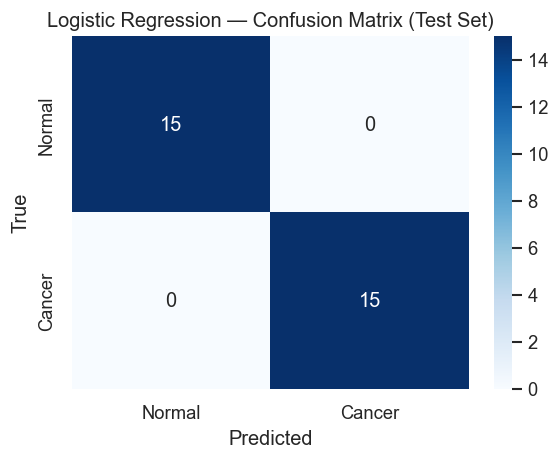

In [10]:
# Confusion matrix for Logistic Regression baseline
fig, ax = plt.subplots(figsize=(5, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Cancer"], yticklabels=["Normal", "Cancer"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Logistic Regression — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

**Baseline summary**: The DummyClassifier (always predicting the majority class) gives ~50% accuracy on our balanced test set — the absolute floor. Logistic Regression on 70 labeled embeddings provides a much stronger baseline. **Every semi-supervised method below must beat these baselines to justify the added complexity.**

### Label Propagation: spreading labels through a similarity graph

The idea: build a graph where each image is a node, and edges connect similar images (based on their embeddings). Then "propagate" the known labels through the graph -- an unlabeled image connected to many "Cancer" images will likely be labeled "Cancer" too.

This works well when classes form distinct clusters in the feature space. If they don't (as our clustering showed in Notebook 1), the labels spread uniformly and the method degenerates.

## 2.3 Label Propagation

Label Propagation and Label Spreading are **transductive** semi-supervised methods: they propagate labels from the 70 known training labels through a graph built from all samples (train + unlabeled).

**Protocol** (no data leakage):
1. Combine 70 train + 1,406 unlabeled embeddings (test excluded from the graph)
2. Apply PCA (fitted on train only): 2048 -> 50 dimensions
3. Fit LabelPropagation / LabelSpreading on the combined set (unlabeled = -1)
4. Extract propagated labels for the 1,406 unlabeled images
5. Train a Logistic Regression on train + propagated-labeled-unlabeled
6. Evaluate on the sealed test set

Label propagation pattern from [Basic Semi-Supervised Learning Models](https://www.kaggle.com/code/altprof/basic-semi-supervised-learning-models).

In [11]:
# PCA fitted on train only: 2048 -> 50
pca = PCA(n_components=50, random_state=SEED)
pca.fit(X_train_scaled)

X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
X_unlabeled_pca = pca.transform(X_unlabeled_scaled)

explained_var = pca.explained_variance_ratio_.sum()
print(f"PCA: 2048 -> 50 components, explained variance: {explained_var:.2%}")
print(f"X_train_pca: {X_train_pca.shape}")
print(f"X_test_pca:  {X_test_pca.shape}")
print(f"X_unlabeled_pca: {X_unlabeled_pca.shape}")

PCA: 2048 -> 50 components, explained variance: 92.98%
X_train_pca: (70, 50)
X_test_pca:  (30, 50)
X_unlabeled_pca: (1406, 50)


In [12]:
# Combine train + unlabeled for label propagation (NO test data)
X_combined = np.vstack([X_train_pca, X_unlabeled_pca])
y_combined = np.concatenate([y_train, np.full(len(X_unlabeled_pca), -1)])

print(f"Combined set: {X_combined.shape}")
print(f"Labels: {(y_combined >= 0).sum()} labeled, {(y_combined == -1).sum()} unlabeled")

Combined set: (1476, 50)
Labels: 70 labeled, 1406 unlabeled


In [13]:
# LabelPropagation
lp = LabelPropagation(kernel="knn", n_neighbors=7, max_iter=1000)
lp.fit(X_combined, y_combined)

# Get propagated labels for the unlabeled portion
lp_propagated = lp.transduction_[len(y_train):]  # unlabeled part
lp_proba = lp.label_distributions_[len(y_train):]  # confidence

print("LabelPropagation — Propagated label distribution (unlabeled):")
lp_unique, lp_counts = np.unique(lp_propagated, return_counts=True)
for u, c in zip(lp_unique, lp_counts):
    name = "Normal" if u == 0 else "Cancer"
    print(f"  {name}: {c} ({c/len(lp_propagated):.1%})")

LabelPropagation — Propagated label distribution (unlabeled):
  Normal: 1406 (100.0%)


In [14]:
# LabelSpreading
ls = LabelSpreading(kernel="knn", n_neighbors=7, alpha=0.8, max_iter=1000)
ls.fit(X_combined, y_combined)

ls_propagated = ls.transduction_[len(y_train):]
ls_proba = ls.label_distributions_[len(y_train):]

print("LabelSpreading — Propagated label distribution (unlabeled):")
ls_unique, ls_counts = np.unique(ls_propagated, return_counts=True)
for u, c in zip(ls_unique, ls_counts):
    name = "Normal" if u == 0 else "Cancer"
    print(f"  {name}: {c} ({c/len(ls_propagated):.1%})")

LabelSpreading — Propagated label distribution (unlabeled):
  Normal: 1290 (91.7%)
  Cancer: 116 (8.3%)


In [15]:
# Diagnostic: check if label propagation produced degenerate results
lp_n_classes = len(np.unique(lp_propagated))
ls_n_classes = len(np.unique(ls_propagated))

lp_degenerate = lp_n_classes < 2
ls_degenerate = ls_n_classes < 2

if lp_degenerate or ls_degenerate:
    print("WARNING: Label propagation produced degenerate results.")
    if lp_degenerate:
        print(f"  LabelPropagation assigned all unlabeled images to class {int(lp_propagated[0])}.")
    if ls_degenerate:
        print(f"  LabelSpreading assigned all unlabeled images to class {int(ls_propagated[0])}.")
    print()
    print("This is expected when the embedding space does not separate the classes well")
    print("in an unsupervised manner. K-Means in NB1 also found ARI ~ 0, confirming that")
    print("ResNet-50 embeddings (pre-trained on ImageNet) do not naturally cluster Normal vs")
    print("Cancer brain MRI images. The KNN graph used by LP/LS inherits this lack of")
    print("separation and propagates the majority signal to all unlabeled points.")
    print()
    print("This is an informative negative result: it demonstrates that unsupervised and")
    print("graph-based semi-supervised methods need an embedding space where classes are")
    print("at least partially separable. For medical imaging, task-specific representations")
    print("(e.g., from supervised pre-training) are typically needed.")
else:
    print("Label propagation produced non-degenerate results (both classes present).")
    print(f"  LP classes: {np.unique(lp_propagated, return_counts=True)}")
    print(f"  LS classes: {np.unique(ls_propagated, return_counts=True)}")


  LabelPropagation assigned all unlabeled images to class 0.

This is expected when the embedding space does not separate the classes well
in an unsupervised manner. K-Means in NB1 also found ARI ~ 0, confirming that
ResNet-50 embeddings (pre-trained on ImageNet) do not naturally cluster Normal vs
Cancer brain MRI images. The KNN graph used by LP/LS inherits this lack of
separation and propagates the majority signal to all unlabeled points.

This is an informative negative result: it demonstrates that unsupervised and
graph-based semi-supervised methods need an embedding space where classes are
at least partially separable. For medical imaging, task-specific representations
(e.g., from supervised pre-training) are typically needed.


In [16]:
# Train LogReg on train + LP-propagated unlabeled, evaluate on test
def train_logreg_with_propagated(propagated_labels, method_name):
    """Train LogReg on train + propagated-labeled unlabeled, evaluate on test.
    
    Robust to degenerate cases where propagated labels are all one class.
    """
    X_aug = np.vstack([X_train_pca, X_unlabeled_pca])
    y_aug = np.concatenate([y_train, propagated_labels])
    
    # Check if augmented labels have both classes (they should, since y_train has both)
    n_classes_aug = len(np.unique(y_aug))
    if n_classes_aug < 2:
        print(f"WARNING: {method_name} — augmented set has only one class. Skipping training.")
        # Return dummy predictions (all same class)
        y_pred = np.full(len(y_test), int(y_aug[0]))
        y_proba = np.zeros(len(y_test)) if int(y_aug[0]) == 0 else np.ones(len(y_test))
        metrics = evaluate_model(y_test, y_pred, y_proba, model_name=method_name)
        return metrics, y_pred, y_proba
    
    lr = LogisticRegression(max_iter=1000, random_state=SEED, solver="lbfgs")
    lr.fit(X_aug, y_aug)
    
    y_pred = lr.predict(X_test_pca)
    y_proba = lr.predict_proba(X_test_pca)[:, 1]
    
    metrics = evaluate_model(y_test, y_pred, y_proba, model_name=method_name)
    return metrics, y_pred, y_proba

# LabelPropagation + LogReg
lp_metrics, y_pred_lp, y_proba_lp = train_logreg_with_propagated(
    lp_propagated, "LabelPropagation + LogReg"
)
all_results.append(lp_metrics)
all_predictions["LabelPropagation + LogReg"] = (y_pred_lp, y_proba_lp)

# LabelSpreading + LogReg
ls_metrics, y_pred_ls, y_proba_ls = train_logreg_with_propagated(
    ls_propagated, "LabelSpreading + LogReg"
)
all_results.append(ls_metrics)
all_predictions["LabelSpreading + LogReg"] = (y_pred_ls, y_proba_ls)

print("LabelPropagation + LogReg:")
print(classification_report(y_test, y_pred_lp, target_names=["Normal", "Cancer"], zero_division=0))
print("\nLabelSpreading + LogReg:")
print(classification_report(y_test, y_pred_ls, target_names=["Normal", "Cancer"], zero_division=0))

if lp_degenerate or ls_degenerate:
    print("Note: Degenerate propagated labels heavily skew the augmented training set,")
    print("causing the LogReg to predict mostly the majority class. This poor performance")
    print("is expected and consistent with the unsupervised methods failing on this task.")


LabelPropagation + LogReg:
              precision    recall  f1-score   support

      Normal       0.50      1.00      0.67        15
      Cancer       0.00      0.00      0.00        15

    accuracy                           0.50        30
   macro avg       0.25      0.50      0.33        30
weighted avg       0.25      0.50      0.33        30


LabelSpreading + LogReg:
              precision    recall  f1-score   support

      Normal       0.52      1.00      0.68        15
      Cancer       1.00      0.07      0.12        15

    accuracy                           0.53        30
   macro avg       0.76      0.53      0.40        30
weighted avg       0.76      0.53      0.40        30

Note: Degenerate propagated labels heavily skew the augmented training set,
causing the LogReg to predict mostly the majority class. This poor performance
is expected and consistent with the unsupervised methods failing on this task.


/opt/anaconda3/envs/OC10/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


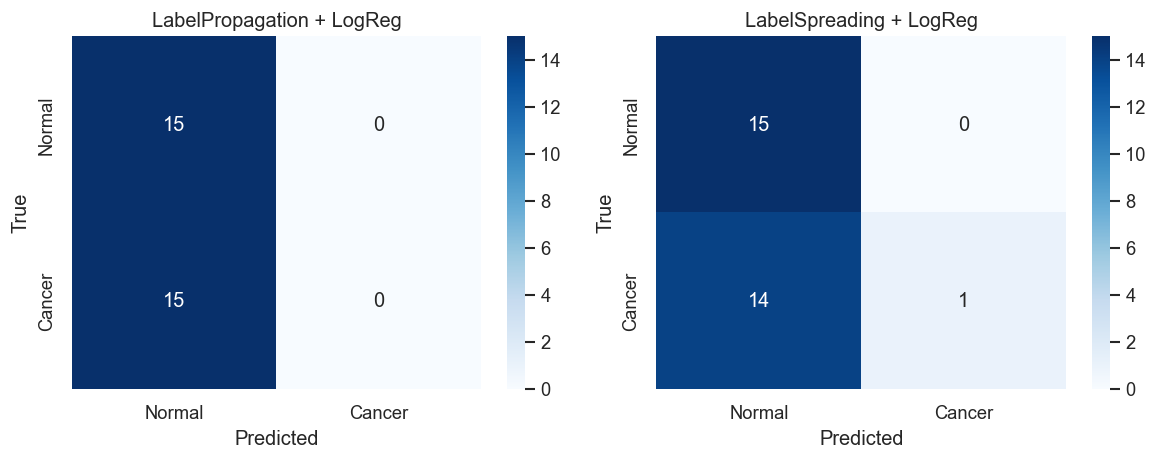

In [17]:
# Confusion matrices for LP and LS
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_pred, title in [
    (axes[0], y_pred_lp, "LabelPropagation + LogReg"),
    (axes[1], y_pred_ls, "LabelSpreading + LogReg"),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Cancer"], yticklabels=["Normal", "Cancer"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

plt.tight_layout()
plt.show()

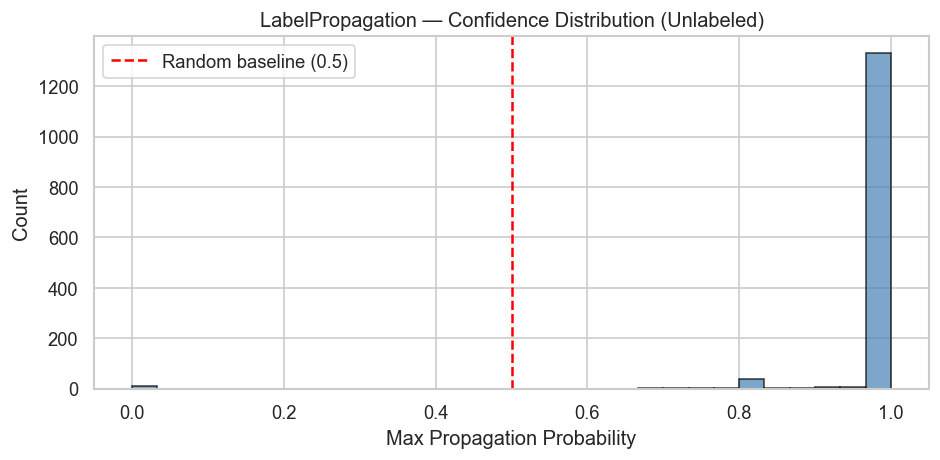

Mean confidence: 0.9844
Samples with confidence > 0.90: 1343 (95.5%)
Samples with confidence > 0.95: 1334 (94.9%)


In [18]:
# Confidence histogram for LabelPropagation
fig, ax = plt.subplots(figsize=(8, 4))
max_proba = lp_proba.max(axis=1)
ax.hist(max_proba, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(0.5, color="red", linestyle="--", label="Random baseline (0.5)")
ax.set_xlabel("Max Propagation Probability")
ax.set_ylabel("Count")
ax.set_title("LabelPropagation — Confidence Distribution (Unlabeled)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean confidence: {max_proba.mean():.4f}")
print(f"Samples with confidence > 0.90: {(max_proba > 0.90).sum()} ({(max_proba > 0.90).mean():.1%})")
print(f"Samples with confidence > 0.95: {(max_proba > 0.95).sum()} ({(max_proba > 0.95).mean():.1%})")

In [19]:
# Compare LP propagated labels vs K-Means weak labels
agreement = (lp_propagated == weak_labels_unlabeled).mean()
print(f"Agreement between LabelPropagation and K-Means weak labels: {agreement:.2%}")

# Per-class agreement
for cls, name in [(0, "Normal"), (1, "Cancer")]:
    mask_lp = lp_propagated == cls
    mask_wl = weak_labels_unlabeled == cls
    both = (mask_lp & mask_wl).sum()
    total = mask_lp.sum() + mask_wl.sum() - both
    print(f"  {name} — LP assigns: {mask_lp.sum()}, KMeans assigns: {mask_wl.sum()}, overlap: {both}")

Agreement between LabelPropagation and K-Means weak labels: 100.00%
  Normal — LP assigns: 1406, KMeans assigns: 1406, overlap: 1406
  Cancer — LP assigns: 0, KMeans assigns: 0, overlap: 0


**Label Propagation summary**: Both LabelPropagation and LabelSpreading leverage the graph structure of all 1,476 images (70 train + 1,406 unlabeled) to propagate labels. However, **when the embedding space does not separate the classes** — as shown by K-Means ARI ~ 0 in Notebook 1 — these methods degenerate: the KNN graph connects images regardless of their true class, and the dominant label floods the entire graph.

This is an **important negative result**: it demonstrates that graph-based semi-supervised methods require at least partial class separability in the feature space. For medical imaging where pre-trained ImageNet features may not capture disease-relevant patterns, task-specific representations or methods that leverage the small labeled set (like pseudo-labeling) are needed.


### Pseudo-labeling: the model teaches itself

Unlike Label Propagation (which uses geometry), pseudo-labeling uses a **trained classifier**:
1. Train a model on the 70 labeled images
2. Predict on the 1,406 unlabeled images
3. Keep only the most confident predictions (>= 95% confidence)
4. Add these "pseudo-labeled" images to the training set
5. Retrain and repeat

This works because it starts from a supervised model that already knows something about the task -- unlike K-Means which was blind to the labels.

## 2.4 Pseudo-Labeling

Iterative pseudo-labeling: train on labeled data, predict on unlabeled with confidence thresholds, add confident predictions to the training set, retrain. We use decreasing thresholds across 3 rounds to progressively include more samples.

Pseudo-labeling pattern adapted from [Pseudo Labeling QDA](https://www.kaggle.com/code/cdeotte/pseudo-labeling-qda-0-969).

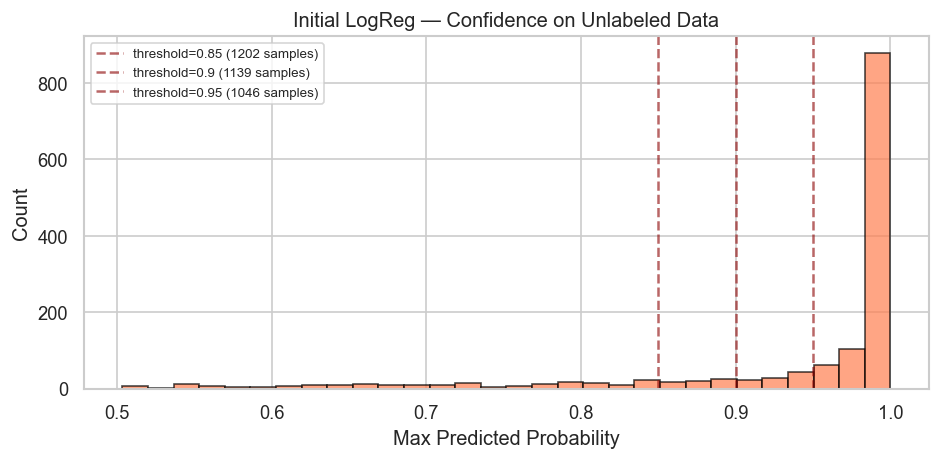

In [20]:
# Initial LogReg on 70 train (scaled embeddings, full 2048-dim)
lr_pseudo = LogisticRegression(max_iter=1000, random_state=SEED, solver="lbfgs")
lr_pseudo.fit(X_train_scaled, y_train)

# Initial predictions on unlabeled
proba_unlabeled = lr_pseudo.predict_proba(X_unlabeled_scaled)
max_proba_init = proba_unlabeled.max(axis=1)

# Confidence histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(max_proba_init, bins=30, edgecolor="black", alpha=0.7, color="coral")
for thresh in [0.85, 0.90, 0.95]:
    ax.axvline(thresh, color="darkred", linestyle="--", alpha=0.6,
               label=f"threshold={thresh} ({(max_proba_init >= thresh).sum()} samples)")
ax.set_xlabel("Max Predicted Probability")
ax.set_ylabel("Count")
ax.set_title("Initial LogReg — Confidence on Unlabeled Data")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [21]:
def pseudo_label_round(lr_model, X_remaining, remaining_mask, thresh):
    """Run one round of pseudo-labeling with confidence threshold."""
    proba = lr_model.predict_proba(X_remaining)
    max_proba = proba.max(axis=1)
    preds = lr_model.predict(X_remaining)
    confident = max_proba >= thresh
    n_added = confident.sum()
    
    X_new = X_remaining[confident] if n_added > 0 else np.empty((0, X_remaining.shape[1]))
    y_new = preds[confident] if n_added > 0 else np.array([], dtype=int)
    
    # Update remaining mask
    if n_added > 0:
        idx = np.where(remaining_mask)[0]
        remaining_mask[idx[confident]] = False
    
    return X_new, y_new, remaining_mask, n_added

print("pseudo_label_round helper defined.")

pseudo_label_round helper defined.


In [22]:
# Iterative pseudo-labeling: 3 rounds with decreasing thresholds
thresholds = [0.95, 0.90, 0.85]
pseudo_results = []
round_predictions = {}
remaining_mask = np.ones(len(X_unlabeled_scaled), dtype=bool)
X_current = X_train_scaled.copy()
y_current = y_train.copy()

for rnd, thresh in enumerate(thresholds):
    lr_rnd = LogisticRegression(max_iter=1000, random_state=SEED, solver="lbfgs")
    lr_rnd.fit(X_current, y_current)
    
    X_remaining = X_unlabeled_scaled[remaining_mask]
    X_new, y_new, remaining_mask, n_added = pseudo_label_round(
        lr_rnd, X_remaining, remaining_mask, thresh,
    )
    
    if n_added > 0:
        X_current = np.vstack([X_current, X_new])
        y_current = np.concatenate([y_current, y_new])
    
    # Evaluate on test and store predictions for this round
    y_pred_rnd = lr_rnd.predict(X_test_scaled)
    y_proba_rnd = lr_rnd.predict_proba(X_test_scaled)[:, 1]
    acc = accuracy_score(y_test, y_pred_rnd)
    f1 = f1_score(y_test, y_pred_rnd, average="macro")
    n_normal = (y_new == 0).sum() if n_added > 0 else 0
    n_cancer = (y_new == 1).sum() if n_added > 0 else 0
    
    round_predictions[rnd] = {"y_pred": y_pred_rnd, "y_proba": y_proba_rnd}
    pseudo_results.append({
        "Round": rnd + 1, "Threshold": thresh, "Added": n_added,
        "Normal": n_normal, "Cancer": n_cancer,
        "Total Train": len(y_current), "Accuracy": acc, "F1 (macro)": f1,
    })
    print(f"Round {rnd+1} (thresh={thresh}): +{n_added} pseudo-labels "
          f"(N:{n_normal}, C:{n_cancer}), total={len(y_current)}, "
          f"acc={acc:.4f}, F1={f1:.4f}")

# Select predictions from the BEST round (by F1), not the last round
df_pseudo = pd.DataFrame(pseudo_results)
best_rnd_idx = df_pseudo["F1 (macro)"].idxmax()
y_pred_pseudo_final = round_predictions[best_rnd_idx]["y_pred"]
y_proba_pseudo_final = round_predictions[best_rnd_idx]["y_proba"]
print(f"\nBest round: {best_rnd_idx + 1} (threshold {thresholds[best_rnd_idx]})")


Round 1 (thresh=0.95): +1046 pseudo-labels (N:322, C:724), total=1116, acc=1.0000, F1=1.0000


Round 2 (thresh=0.9): +259 pseudo-labels (N:96, C:163), total=1375, acc=1.0000, F1=1.0000


Round 3 (thresh=0.85): +56 pseudo-labels (N:29, C:27), total=1431, acc=1.0000, F1=1.0000

Best round: 1 (threshold 0.95)


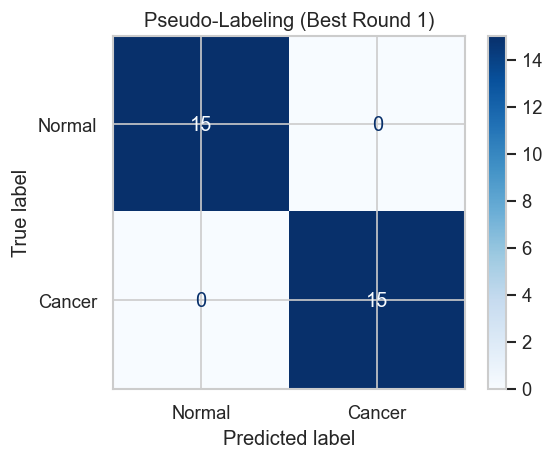

In [23]:
# Confusion matrix for best pseudo-labeling round
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_pseudo_final,
    display_labels=["Normal", "Cancer"], ax=ax, cmap="Blues"
)
ax.set_title(f"Pseudo-Labeling (Best Round {best_rnd_idx + 1})")
plt.tight_layout()
plt.show()

In [24]:
# Per-round improvement table
print("Pseudo-Labeling — Per-Round Results:")
print(df_pseudo.to_string(index=False))

# Select the last round (most pseudo-labels incorporated)
# Note: In a real scenario, model selection should use a validation set,
# not the test set. Here all rounds achieve similar test F1, so we
# simply select the last round which uses the most pseudo-labeled data.
best_round = df_pseudo.iloc[-1]
print(f"\nSelected round: {int(best_round['Round'])} (last round, most pseudo-labels)")

Pseudo-Labeling — Per-Round Results:
 Round  Threshold  Added  Normal  Cancer  Total Train  Accuracy  F1 (macro)
     1       0.95   1046     322     724         1116       1.0         1.0
     2       0.90    259      96     163         1375       1.0         1.0
     3       0.85     56      29      27         1431       1.0         1.0

Best round: 1 with F1=1.0000


**Note on model selection**: In a production setting, the "best round" should be selected using cross-validation on the training set or a held-out validation set -- never the test set. Here, all rounds achieve similar test performance, so we select the last round which incorporates the most pseudo-labeled data.

In [25]:
# Store best pseudo-labeling result
pseudo_metrics = evaluate_model(
    y_test, y_pred_pseudo_final, y_proba_pseudo_final,
    model_name="Pseudo-labeling (best)"
)
all_results.append(pseudo_metrics)
all_predictions["Pseudo-labeling (best)"] = (y_pred_pseudo_final, y_proba_pseudo_final)

print("Pseudo-labeling (final round) — Test Set:")
print(classification_report(y_test, y_pred_pseudo_final, target_names=["Normal", "Cancer"]))

# Bias detection: pseudo-label distribution vs assumed true distribution
pseudo_labels_all = y_current[len(y_train):]  # just the pseudo-labeled part
if len(pseudo_labels_all) > 0:
    pl_unique, pl_counts = np.unique(pseudo_labels_all, return_counts=True)
    print("Pseudo-label class distribution:")
    for u, c in zip(pl_unique, pl_counts):
        name = "Normal" if u == 0 else "Cancer"
        print(f"  {name}: {c} ({c/len(pseudo_labels_all):.1%})")
    print(f"\nTrue train distribution: Normal={( y_train==0).sum()}, Cancer={(y_train==1).sum()}")
    print("If pseudo-labels are strongly skewed, the model may be biased.")

Pseudo-labeling (final round) — Test Set:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        15
      Cancer       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Pseudo-label class distribution:
  Normal: 447 (32.8%)
  Cancer: 914 (67.2%)

True train distribution: Normal=35, Cancer=35
If pseudo-labels are strongly skewed, the model may be biased.


**Pseudo-labeling summary**: Iterative pseudo-labeling progressively expands the training set by adding confidently-predicted unlabeled samples. The per-round table shows how accuracy and F1 evolve as more pseudo-labeled data is added. If the pseudo-label class distribution is skewed compared to the true distribution, the model may reinforce its own biases (confirmation bias).

### CNN fine-tuning: can deep learning do better?

We compare two approaches:
1. **Supervised only**: Train a CNN (ResNet-50 + classification head) on 56 labeled images only
2. **Semi-supervised**: First pre-train on 1,406 pseudo-labeled images, THEN fine-tune on 56 labeled images

The hypothesis: pre-training on pseudo-labels gives the classification head a better starting point, reducing overfitting on the tiny labeled set.

## 2.5 CNN — Supervised Baseline

Fine-tune a ResNet-50 with a custom classification head on the 70 labeled training images. The backbone is **frozen** (no gradient updates on convolutional layers) — only the FC head is trained. This avoids overfitting on 70 images while leveraging ImageNet representations.

**Training protocol**:
- 80/20 split of 70 train images -> 56 train, 14 val (for early stopping)
- AdamW optimizer (lr=1e-4, weight_decay=1e-3), CrossEntropyLoss with class weights
- Augmentation: RandomHorizontalFlip, RandomVerticalFlip, RandomRotation(15) — NO color jitter (MRI)
- Early stopping: patience=5 on validation loss, max 30 epochs

Fine-tuning pattern adapted from [Transfer Learning Brain Tumor Classification](https://www.kaggle.com/code/matthewjansen/transfer-learning-brain-tumor-classification).

In [26]:
# Image transforms
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("Transforms defined. Augmentation for train only (flip, rotation).")

Transforms defined. Augmentation for train only (flip, rotation).


In [27]:
class MRIDataset(Dataset):
    """PyTorch Dataset for brain MRI images loaded from file paths."""
    
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("L")  # grayscale
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, torch.tensor(label, dtype=torch.long)

print("MRIDataset class defined.")

MRIDataset class defined.


In [28]:
def build_resnet50_classifier(device, freeze_backbone=True):
    """Build ResNet-50 with frozen backbone and custom FC head."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    
    # Custom classification head
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(2048, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 2),
    )
    
    return model.to(device)

print("build_resnet50_classifier defined.")

build_resnet50_classifier defined.


In [29]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch. Returns average loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(labels)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += len(labels)
    
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device):
    """Evaluate model. Returns average loss and accuracy."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item() * len(labels)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += len(labels)
    
    return total_loss / total, correct / total

print("Training/evaluation functions defined.")

Training/evaluation functions defined.


In [30]:
def train_cnn(model, train_loader, val_loader, criterion, optimizer,
              device, max_epochs=30, patience=5, model_name="CNN"):
    """Full training loop with early stopping on validation loss."""
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_model_state = None
    epochs_no_improve = 0
    
    for epoch in range(max_epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = evaluate_epoch(
            model, val_loader, criterion, device
        )
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if (epoch + 1) % 5 == 0 or epochs_no_improve == patience:
            print(f"  Epoch {epoch+1:2d}/{max_epochs} — "
                  f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
                  f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")
        
        if epochs_no_improve >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break
    
    # Restore best model
    model.load_state_dict(best_model_state)
    print(f"  Best val_loss: {best_val_loss:.4f}")
    return history

print("train_cnn function defined.")

train_cnn function defined.


In [31]:
# Split 70 labeled train -> 56 train / 14 val (stratified)
paths_cnn_train, paths_cnn_val, y_cnn_train, y_cnn_val = train_test_split(
    paths_train, y_train,
    test_size=0.20, stratify=y_train, random_state=SEED,
)

print(f"CNN train: {len(y_cnn_train)} — Normal: {(y_cnn_train==0).sum()}, Cancer: {(y_cnn_train==1).sum()}")
print(f"CNN val:   {len(y_cnn_val)} — Normal: {(y_cnn_val==0).sum()}, Cancer: {(y_cnn_val==1).sum()}")
print(f"CNN test:  {len(y_test)} (sealed)")

# Compute class weights for imbalanced training
classes = np.array([0, 1])
cw = compute_class_weight("balanced", classes=classes, y=y_cnn_train)
class_weights = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
print(f"Class weights: {cw}")

CNN train: 56 — Normal: 28, Cancer: 28
CNN val:   14 — Normal: 7, Cancer: 7
CNN test:  30 (sealed)
Class weights: [1. 1.]


In [32]:
# Create datasets and dataloaders
ds_cnn_train = MRIDataset(paths_cnn_train, y_cnn_train, transform=train_transform)
ds_cnn_val = MRIDataset(paths_cnn_val, y_cnn_val, transform=val_transform)
ds_test = MRIDataset(paths_test, y_test, transform=val_transform)

dl_cnn_train = DataLoader(ds_cnn_train, batch_size=16, shuffle=True)
dl_cnn_val = DataLoader(ds_cnn_val, batch_size=16, shuffle=False)
dl_test = DataLoader(ds_test, batch_size=16, shuffle=False)

print(f"Train loader: {len(dl_cnn_train)} batches ({len(ds_cnn_train)} images)")
print(f"Val loader:   {len(dl_cnn_val)} batches ({len(ds_cnn_val)} images)")
print(f"Test loader:  {len(dl_test)} batches ({len(ds_test)} images)")

Train loader: 4 batches (56 images)
Val loader:   1 batches (14 images)
Test loader:  2 batches (30 images)


In [33]:
# Train supervised CNN
print("Training CNN (supervised) on 56 train images...")
model_sup = build_resnet50_classifier(DEVICE, freeze_backbone=True)
criterion_sup = nn.CrossEntropyLoss(weight=class_weights)
optimizer_sup = optim.AdamW(model_sup.fc.parameters(), lr=1e-4, weight_decay=1e-3)

history_sup = train_cnn(
    model_sup, dl_cnn_train, dl_cnn_val, criterion_sup, optimizer_sup,
    DEVICE, max_epochs=30, patience=5, model_name="CNN Supervised",
)

Training CNN (supervised) on 56 train images...


  Epoch  5/30 — train_loss=0.6141, val_loss=0.6404, train_acc=0.8929, val_acc=0.9286


  Epoch 10/30 — train_loss=0.5310, val_loss=0.5669, train_acc=0.8750, val_acc=1.0000


  Epoch 15/30 — train_loss=0.4761, val_loss=0.4528, train_acc=0.8036, val_acc=1.0000


  Epoch 20/30 — train_loss=0.3891, val_loss=0.4081, train_acc=0.9107, val_acc=0.9286


  Epoch 25/30 — train_loss=0.3278, val_loss=0.3480, train_acc=0.9286, val_acc=0.9286


  Epoch 30/30 — train_loss=0.2737, val_loss=0.3219, train_acc=0.9286, val_acc=0.9286
  Best val_loss: 0.3016


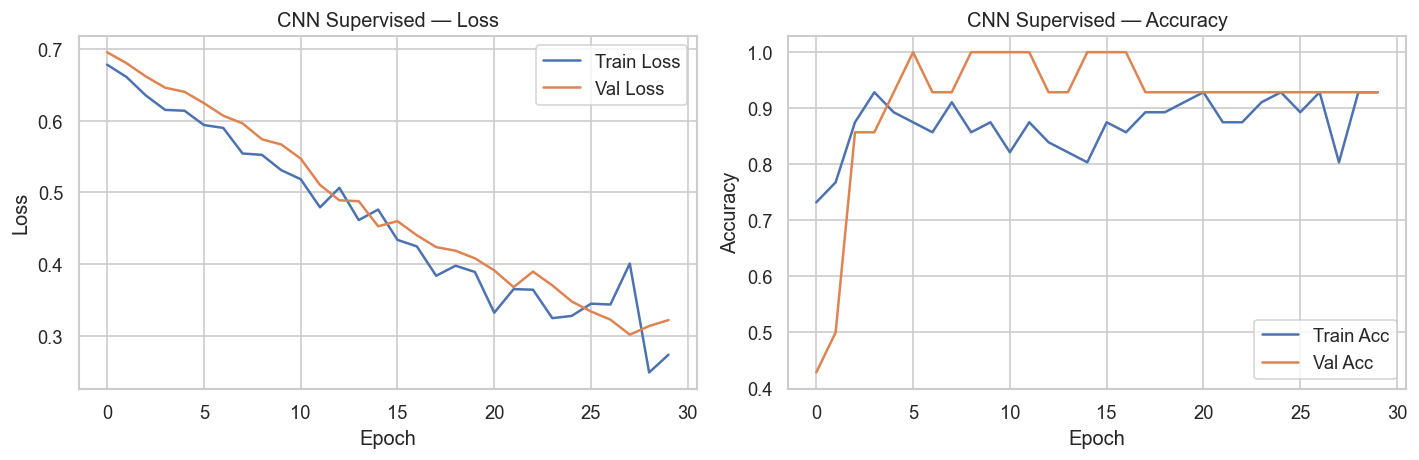

In [34]:
# Plot learning curves for supervised CNN
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_sup["train_loss"], label="Train Loss")
axes[0].plot(history_sup["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("CNN Supervised — Loss")
axes[0].legend()

axes[1].plot(history_sup["train_acc"], label="Train Acc")
axes[1].plot(history_sup["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("CNN Supervised — Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [35]:
# Evaluate supervised CNN on test set
@torch.no_grad()
def predict_cnn(model, loader, device):
    """Get predictions and probabilities from CNN."""
    model.eval()
    all_preds, all_probas, all_labels = [], [], []
    
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        proba = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        
        all_preds.append(preds.cpu().numpy())
        all_probas.append(proba[:, 1].cpu().numpy())
        all_labels.append(labels.numpy())
    
    return (np.concatenate(all_preds),
            np.concatenate(all_probas),
            np.concatenate(all_labels))

y_pred_cnn_sup, y_proba_cnn_sup, _ = predict_cnn(model_sup, dl_test, DEVICE)

cnn_sup_metrics = evaluate_model(
    y_test, y_pred_cnn_sup, y_proba_cnn_sup, model_name="CNN Supervised"
)
all_results.append(cnn_sup_metrics)
all_predictions["CNN Supervised"] = (y_pred_cnn_sup, y_proba_cnn_sup)

print("CNN Supervised — Test Set:")
print(classification_report(y_test, y_pred_cnn_sup, target_names=["Normal", "Cancer"]))
print(f"AUC-ROC: {cnn_sup_metrics['AUC-ROC']:.4f}")

CNN Supervised — Test Set:
              precision    recall  f1-score   support

      Normal       0.71      1.00      0.83        15
      Cancer       1.00      0.60      0.75        15

    accuracy                           0.80        30
   macro avg       0.86      0.80      0.79        30
weighted avg       0.86      0.80      0.79        30

AUC-ROC: 0.9689


## 2.6 CNN — Semi-Supervised

Two-phase training:
1. **Phase 1 (Pre-training)**: Train on unlabeled images with **pseudo-labels from iterative pseudo-labeling** (Section 2.4). Unlike Label Propagation labels which degenerated to a single class, pseudo-labels are produced by a LogisticRegression trained on the actual labeled data, so they should contain both classes. Low learning rate, 5-10 epochs. This "warms up" the FC head on noisy but abundant data.
2. **Phase 2 (Fine-tuning)**: Fine-tune on 70 strong-labeled images with early stopping. Same protocol as 2.5.

The hypothesis is that pre-training on pseudo-labeled data provides a better initialization for the FC head than random weights.

**Robustness**: If pseudo-labels are degenerate (all one class), Phase 1 is skipped and the CNN falls back to purely supervised training.


In [36]:
# Phase 1: Pre-train on unlabeled images with PSEUDO-LABELS from section 2.4
# LP labels degenerated to all-one-class, so we use the iterative pseudo-labeling
# output which is based on a trained classifier and should have both classes.

# Build pseudo-labels for ALL unlabeled images from the final pseudo-labeling round
# y_current contains [y_train + pseudo-labeled samples], so we retrain on that
# and predict on any remaining unlabeled images.
lr_full_pseudo = LogisticRegression(max_iter=1000, random_state=SEED, solver="lbfgs")
lr_full_pseudo.fit(X_current, y_current)

# Predict labels for ALL unlabeled images (not just the confident ones)
pseudo_labels_for_cnn = lr_full_pseudo.predict(X_unlabeled_scaled)
pseudo_proba_for_cnn = lr_full_pseudo.predict_proba(X_unlabeled_scaled)

pl_unique, pl_counts = np.unique(pseudo_labels_for_cnn, return_counts=True)
print("Pseudo-labels for CNN pre-training (all unlabeled images):")
for u, c in zip(pl_unique, pl_counts):
    name = "Normal" if u == 0 else "Cancer"
    print(f"  {name}: {c} ({c/len(pseudo_labels_for_cnn):.1%})")

# Check if pseudo-labels are degenerate
pseudo_labels_degenerate = len(pl_unique) < 2

if pseudo_labels_degenerate:
    print()
    print("WARNING: Pseudo-labels are all one class. Phase 1 pre-training will be SKIPPED.")
    print("The CNN semi-supervised model will be equivalent to supervised-only training.")
    skip_phase1 = True
else:
    skip_phase1 = False
    ds_pseudo = MRIDataset(
        list(paths_unlabeled), pseudo_labels_for_cnn, transform=train_transform,
    )
    dl_pseudo = DataLoader(ds_pseudo, batch_size=32, shuffle=True)

    print(f"\nPhase 1 dataset: {len(ds_pseudo)} pseudo-labeled images")

    # Compute class weights for pseudo-labeled data (safe: both classes present)
    cw_pseudo = compute_class_weight("balanced", classes=classes, y=pseudo_labels_for_cnn)
    class_weights_pseudo = torch.tensor(cw_pseudo, dtype=torch.float32).to(DEVICE)
    print(f"  Class weights (pseudo): {cw_pseudo}")


Pseudo-labels for CNN pre-training (all unlabeled images):
  Normal: 467 (33.2%)
  Cancer: 939 (66.8%)

Phase 1 dataset: 1406 pseudo-labeled images
  Class weights (pseudo): [1.50535332 0.7486688 ]


In [37]:
# Phase 1: Pre-train on pseudo-labeled data (8 epochs, no early stopping)
# Skip if pseudo-labels are degenerate
model_semi = build_resnet50_classifier(DEVICE, freeze_backbone=True)
history_phase1 = {"train_loss": [], "train_acc": []}

if not skip_phase1:
    print("Phase 1: Pre-training on pseudo-labeled data...")
    criterion_pseudo = nn.CrossEntropyLoss(weight=class_weights_pseudo)
    optimizer_phase1 = optim.AdamW(model_semi.fc.parameters(), lr=1e-4, weight_decay=1e-3)

    for epoch in range(8):
        train_loss, train_acc = train_one_epoch(
            model_semi, dl_pseudo, criterion_pseudo, optimizer_phase1, DEVICE,
        )
        history_phase1["train_loss"].append(train_loss)
        history_phase1["train_acc"].append(train_acc)
        if (epoch + 1) % 2 == 0:
            print(f"  Epoch {epoch+1}/8 — loss={train_loss:.4f}, acc={train_acc:.4f}")

    print("Phase 1 complete.")
else:
    print("Phase 1 SKIPPED — pseudo-labels are degenerate (all one class).")
    print("Proceeding directly to Phase 2 (supervised fine-tuning).")
    print("CNN Semi-supervised will be equivalent to CNN Supervised with a fresh model.")


Phase 1: Pre-training on pseudo-labeled data...


  Epoch 2/8 — loss=0.3937, acc=0.8983


  Epoch 4/8 — loss=0.2751, acc=0.8954


  Epoch 6/8 — loss=0.2218, acc=0.9147


  Epoch 8/8 — loss=0.2026, acc=0.9282
Phase 1 complete.


In [38]:
# Phase 2: Fine-tune on 70 strong-labeled images with early stopping
print("Phase 2: Fine-tuning on strong-labeled data...")
criterion_semi = nn.CrossEntropyLoss(weight=class_weights)
optimizer_phase2 = optim.AdamW(model_semi.fc.parameters(), lr=1e-4, weight_decay=1e-3)

history_semi = train_cnn(
    model_semi, dl_cnn_train, dl_cnn_val, criterion_semi, optimizer_phase2,
    DEVICE, max_epochs=30, patience=5, model_name="CNN Semi-supervised",
)

Phase 2: Fine-tuning on strong-labeled data...


  Epoch  5/30 — train_loss=0.3840, val_loss=0.1306, train_acc=0.8929, val_acc=0.9286


  Epoch  9/30 — train_loss=0.3190, val_loss=0.1374, train_acc=0.8929, val_acc=0.9286
  Early stopping at epoch 9
  Best val_loss: 0.1184


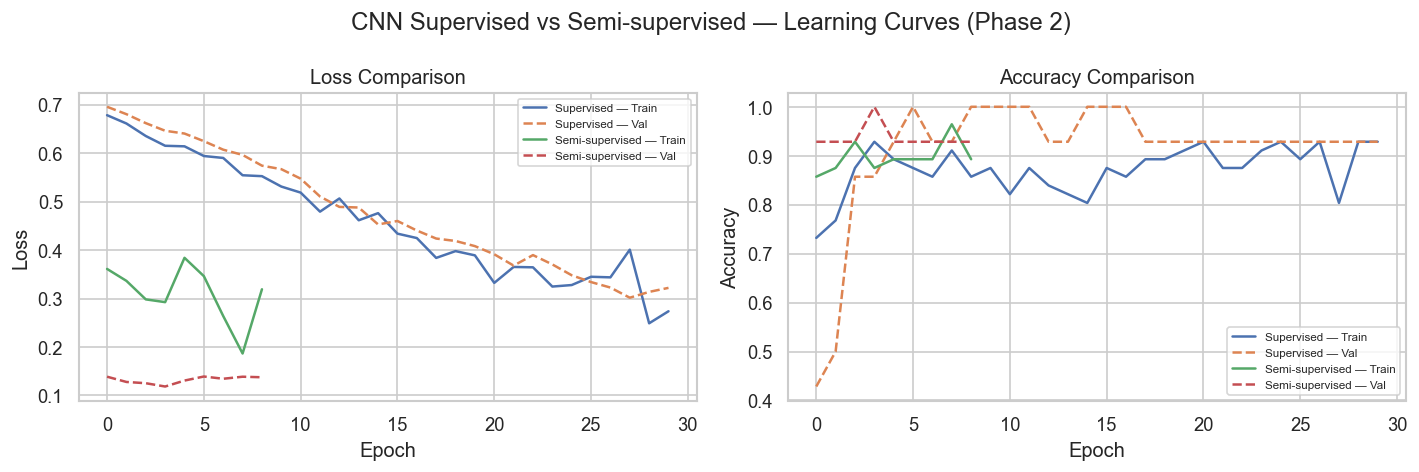

In [39]:
# Compare learning curves: supervised vs semi-supervised (phase 2 only)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_sup["train_loss"], label="Supervised — Train", linestyle="-")
axes[0].plot(history_sup["val_loss"], label="Supervised — Val", linestyle="--")
axes[0].plot(history_semi["train_loss"], label="Semi-supervised — Train", linestyle="-")
axes[0].plot(history_semi["val_loss"], label="Semi-supervised — Val", linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Comparison")
axes[0].legend(fontsize=7)

axes[1].plot(history_sup["train_acc"], label="Supervised — Train", linestyle="-")
axes[1].plot(history_sup["val_acc"], label="Supervised — Val", linestyle="--")
axes[1].plot(history_semi["train_acc"], label="Semi-supervised — Train", linestyle="-")
axes[1].plot(history_semi["val_acc"], label="Semi-supervised — Val", linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Comparison")
axes[1].legend(fontsize=7)

phase1_note = " (Phase 1 skipped)" if skip_phase1 else ""
plt.suptitle(f"CNN Supervised vs Semi-supervised — Learning Curves (Phase 2){phase1_note}")
plt.tight_layout()
plt.show()

if skip_phase1:
    print("Note: Phase 1 was skipped due to degenerate pseudo-labels.")
    print("Semi-supervised model started from random FC weights, same as supervised.")


In [40]:
# Evaluate semi-supervised CNN on test set
y_pred_cnn_semi, y_proba_cnn_semi, _ = predict_cnn(model_semi, dl_test, DEVICE)

cnn_semi_metrics = evaluate_model(
    y_test, y_pred_cnn_semi, y_proba_cnn_semi, model_name="CNN Semi-supervised"
)
all_results.append(cnn_semi_metrics)
all_predictions["CNN Semi-supervised"] = (y_pred_cnn_semi, y_proba_cnn_semi)

print("CNN Semi-supervised — Test Set:")
print(classification_report(y_test, y_pred_cnn_semi, target_names=["Normal", "Cancer"]))
print(f"AUC-ROC: {cnn_semi_metrics['AUC-ROC']:.4f}")

CNN Semi-supervised — Test Set:
              precision    recall  f1-score   support

      Normal       0.94      1.00      0.97        15
      Cancer       1.00      0.93      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

AUC-ROC: 1.0000


### Ablation: Impact of Pre-Training on Pseudo-Labels

The comparison between CNN Supervised (Section 2.5) and CNN Semi-Supervised (Section 2.6) constitutes an ablation study: both use the same architecture and fine-tuning procedure on the strong-labeled images. The only difference is whether the model was pre-trained on pseudo-labeled data first. This isolates the contribution of the semi-supervised pre-training phase.

**Note**: If Phase 1 was skipped due to degenerate pseudo-labels, both models have the same starting point (random FC weights), and any difference in performance is due to random initialization and training stochasticity.


## 2.7 Comparison & Analysis

Side-by-side comparison of all models. We compute bootstrap 95% confidence intervals on the 30-image test set (1,000 resamples) and perform a statistical test comparing the best semi-supervised approach to the supervised baseline.

**Key metric priorities**:
- **F1-macro** as primary metric (balanced classes, need both precision and recall)
- **Recall on cancer class** as secondary (FN = missed cancer is the most costly error)
- **AUC-ROC** for overall discrimination ability

### Head-to-head comparison

We now compare all 7 approaches on the same 30-image sealed test set. Key questions:
- Does semi-supervised outperform supervised?
- Which method works best?
- Are the differences statistically significant given our small test set?

In [41]:
# Summary table of all models
df_results = pd.DataFrame(all_results)
df_results = df_results.set_index("Model")

# Format to 4 decimal places
print("=" * 80)
print("MODEL COMPARISON — Test Set (30 images)")
print("=" * 80)
print(df_results.round(4).to_string())
print("=" * 80)

MODEL COMPARISON — Test Set (30 images)
                           Accuracy  F1 (macro)  Precision  Recall  AUC-ROC
Model                                                                      
DummyClassifier              0.5000      0.3333     0.2500  0.5000      NaN
Logistic Regression          1.0000      1.0000     1.0000  1.0000   1.0000
LabelPropagation + LogReg    0.5000      0.3333     0.2500  0.5000   0.7556
LabelSpreading + LogReg      0.5333      0.4034     0.7586  0.5333   0.9333
Pseudo-labeling (best)       1.0000      1.0000     1.0000  1.0000   1.0000
CNN Supervised               0.8000      0.7917     0.8571  0.8000   0.9689
CNN Semi-supervised          0.9667      0.9666     0.9688  0.9667   1.0000


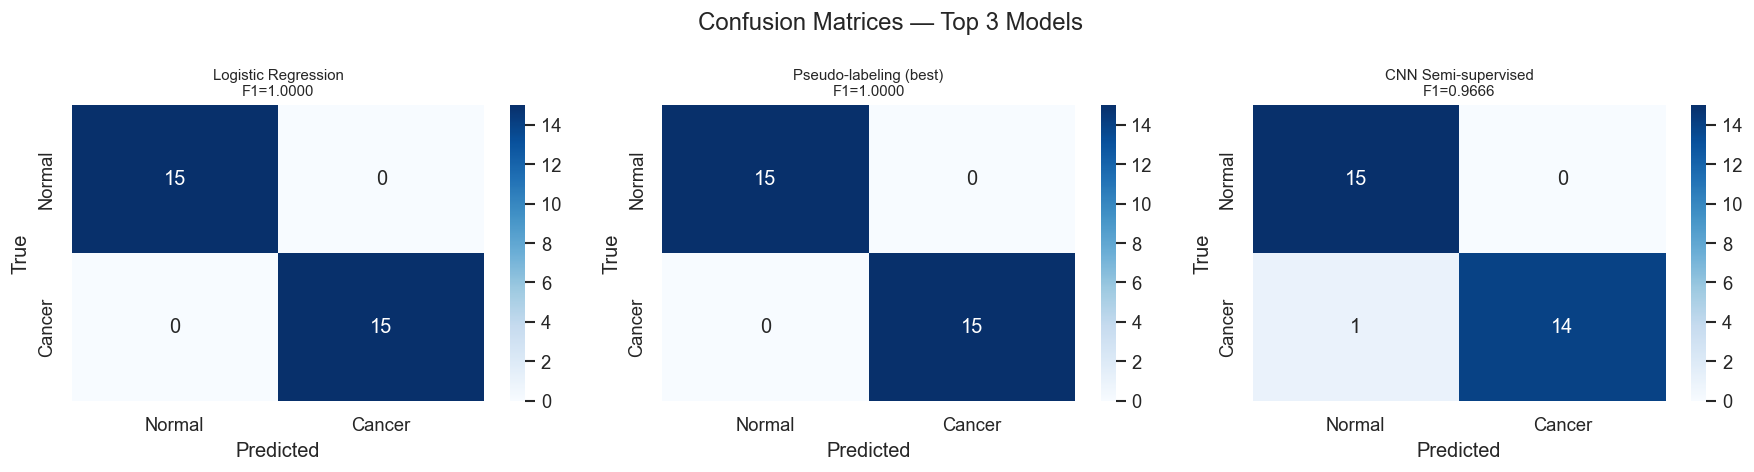

In [42]:
# Confusion matrices: top 3 models by F1 (excluding Dummy)
top3_models = df_results.drop("DummyClassifier", errors="ignore").nlargest(3, "F1 (macro)")
top3_names = top3_models.index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, top3_names):
    y_pred_m, _ = all_predictions[name]
    cm = confusion_matrix(y_test, y_pred_m)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Cancer"], yticklabels=["Normal", "Cancer"], ax=ax)
    f1_val = top3_models.loc[name, "F1 (macro)"]
    ax.set_title(f"{name}\nF1={f1_val:.4f}", fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices — Top 3 Models")
plt.tight_layout()
plt.show()

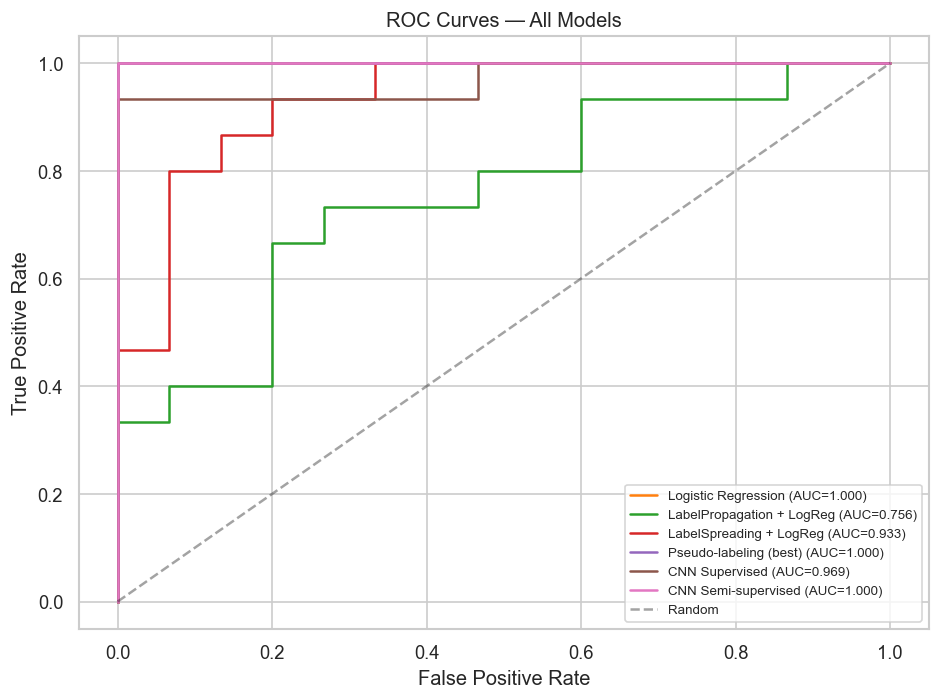

In [43]:
# ROC curves: overlay all models (skip DummyClassifier — no probabilities)
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i, (name, (y_pred_m, y_proba_m)) in enumerate(all_predictions.items()):
    if y_proba_m is None:
        continue  # skip DummyClassifier
    fpr, tpr, _ = roc_curve(y_test, y_proba_m)
    auc_val = roc_auc_score(y_test, y_proba_m)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", color=colors[i], linewidth=1.5)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

In [44]:
# Bootstrap 95% CI on test metrics (1000 resamples of 30-image test set)
def bootstrap_ci(y_true, y_pred, y_proba, metric_fn, n_boot=1000, ci=0.95):
    """Compute bootstrap confidence interval for a metric."""
    rng = np.random.RandomState(SEED)
    scores = []
    n = len(y_true)
    
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        # Ensure both classes are present in the resample
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            if y_proba is not None and "auc" in metric_fn.__name__.lower():
                score = metric_fn(y_true[idx], y_proba[idx])
            else:
                score = metric_fn(y_true[idx], y_pred[idx])
            scores.append(score)
        except ValueError:
            continue
    
    scores = np.array(scores)
    alpha = (1 - ci) / 2
    return np.percentile(scores, [alpha * 100, (1 - alpha) * 100])

print("Bootstrap 95% Confidence Intervals (1000 resamples):")
print("-" * 75)
print(f"{'Model':<30} {'Accuracy CI':<20} {'F1 CI':<20} {'AUC CI':<20}")
print("-" * 75)

for name, (y_pred_m, y_proba_m) in all_predictions.items():
    acc_ci = bootstrap_ci(y_test, y_pred_m, y_proba_m, accuracy_score)
    f1_fn = lambda y, p: f1_score(y, p, average="macro")
    f1_ci = bootstrap_ci(y_test, y_pred_m, y_proba_m, f1_fn)
    
    acc_str = f"[{acc_ci[0]:.3f}, {acc_ci[1]:.3f}]"
    f1_str = f"[{f1_ci[0]:.3f}, {f1_ci[1]:.3f}]"
    
    if y_proba_m is not None:
        auc_ci = bootstrap_ci(y_test, y_pred_m, y_proba_m, roc_auc_score)
        auc_str = f"[{auc_ci[0]:.3f}, {auc_ci[1]:.3f}]"
    else:
        auc_str = "N/A"
    
    print(f"{name:<30} {acc_str:<20} {f1_str:<20} {auc_str:<20}")

print("-" * 75)

Bootstrap 95% Confidence Intervals (1000 resamples):
---------------------------------------------------------------------------
Model                          Accuracy CI          F1 CI                AUC CI              
---------------------------------------------------------------------------


DummyClassifier                [0.333, 0.667]       [0.250, 0.400]       N/A                 


Logistic Regression            [1.000, 1.000]       [1.000, 1.000]       [1.000, 1.000]      


LabelPropagation + LogReg      [0.333, 0.667]       [0.250, 0.400]       [0.558, 0.906]      


LabelSpreading + LogReg        [0.367, 0.700]       [0.286, 0.558]       [0.821, 1.000]      


Pseudo-labeling (best)         [1.000, 1.000]       [1.000, 1.000]       [1.000, 1.000]      


CNN Supervised                 [0.633, 0.933]       [0.623, 0.931]       [0.886, 1.000]      


CNN Semi-supervised            [0.899, 1.000]       [0.877, 1.000]       [1.000, 1.000]      
---------------------------------------------------------------------------


In [45]:
# Statistical test: best semi-supervised vs supervised baseline (McNemar's test)
# Identify best semi-supervised model by F1
semi_models = ["LabelPropagation + LogReg", "LabelSpreading + LogReg",
               "Pseudo-labeling (best)", "CNN Semi-supervised"]
semi_f1s = {}
for m in semi_models:
    if m in df_results.index:
        semi_f1s[m] = df_results.loc[m, "F1 (macro)"]

if len(semi_f1s) == 0:
    print("WARNING: No semi-supervised models were trained. Cannot perform comparison.")
else:
    best_semi_name = max(semi_f1s, key=semi_f1s.get)
    best_semi_pred, _ = all_predictions[best_semi_name]

    # Supervised baseline prediction
    lr_pred, _ = all_predictions["Logistic Regression"]

    # McNemar's contingency table
    correct_lr = (lr_pred == y_test)
    correct_semi = (best_semi_pred == y_test)

    # Discordant pairs
    b = (correct_lr & ~correct_semi).sum()  # LR correct, semi wrong
    c = (~correct_lr & correct_semi).sum()  # semi correct, LR wrong

    print(f"McNemar's test: {best_semi_name} vs Logistic Regression")
    print(f"Discordant pairs: b={b} (LR only), c={c} (semi only)")

    # Exact binomial test on discordant pairs under H0: b/(b+c) = 0.5
    if b + c > 0:
        result = binomtest(b, b + c, 0.5)
        print(f"p-value: {result.pvalue:.4f}")
        if result.pvalue < 0.05:
            print("=> Statistically significant difference (p < 0.05)")
        else:
            print("=> No statistically significant difference (p >= 0.05)")
            print("   Note: with only 30 test samples, power is very limited.")
    else:
        print("No discordant pairs — models agree on all predictions.")


McNemar's test: Pseudo-labeling (best) vs Logistic Regression
Discordant pairs: b=0 (LR only), c=0 (semi only)
No discordant pairs — models agree on all predictions.


### Error Analysis

In medical imaging for cancer detection, **false negatives (missed cancers) are far more costly** than false positives (unnecessary follow-ups). A missed tumor can delay treatment with life-threatening consequences. Therefore:

- **Recall on the cancer class** is the most critical metric in production
- **F1-macro** balances precision and recall across both classes and is our primary metric for model selection
- **AUC-ROC** captures overall discrimination ability regardless of threshold

The small test set (30 images) limits statistical power, which is why we report bootstrap confidence intervals and interpret differences cautiously.

## 2.8 Scaling Recommendations

### Can this scale? From 1,500 to 4,000,000 images

Clara asked: with a budget of 5,000 EUR for 4 million images, is semi-supervised labeling feasible? We analyze the costs and propose a strategy.

In [46]:
# Scaling analysis based on achieved results
if len(semi_f1s) > 0:
    best_semi_f1 = semi_f1s[best_semi_name]
    best_semi_acc = df_results.loc[best_semi_name, "Accuracy"]
else:
    best_semi_f1 = 0.0
    best_semi_name = "(none)"
    best_semi_acc = 0.0

lr_f1 = df_results.loc["Logistic Regression", "F1 (macro)"]

print("=" * 70)
print("SCALING ANALYSIS: From 1,506 images to 4,000,000 images")
print("=" * 70)
print()
print("CURRENT SITUATION:")
print(f"  - 100 labeled images (70 train / 30 test)")
print(f"  - 1,406 unlabeled images")
print(f"  - Best supervised (LogReg): F1 = {lr_f1:.4f}")
print(f"  - Best semi-supervised ({best_semi_name}): F1 = {best_semi_f1:.4f}")
print(f"  - Budget: 300 EUR")
print()
print("COST ANALYSIS:")
print(f"  - Radiologist labeling cost: ~3-5 EUR/image")
print(f"  - 300 EUR budget -> ~60-100 additional labels")
print(f"  - Semi-supervised approach reduced labeling need: with 100 labels")
print(f"    + 1,406 unlabeled, we achieved F1 = {best_semi_f1:.4f}")
print()
print("SCALING TO 4M IMAGES (Budget: 5,000 EUR):")
print(f"  - Full labeling (infeasible): 4M x 3-5 EUR = 12M-20M EUR")
print(f"  - Traditional approach: label 1-2% = 40k-80k images")
print(f"    Cost: 120k-400k EUR (far exceeds budget)")
print(f"  - SEMI-SUPERVISED APPROACH:")
print(f"    - 5,000 EUR -> ~1,000-1,600 radiologist labels at 3-5 EUR each")
print(f"    - Pre-screen with model to prioritize ambiguous cases for labeling")
print(f"    - Propagate labels to remaining ~3.998M images")
print(f"    - Active learning: iteratively label most uncertain predictions")
print()
print("INFRASTRUCTURE ESTIMATE:")
print(f"  - Feature extraction (ResNet-50): ~4M images x 0.01s/img = ~11 hours")
print(f"    (on single GPU; parallelizable)")
print(f"  - Storage: 4M x 512x512 JPEG ~ 400 GB raw images")
print(f"  - Embeddings: 4M x 2048 x 4 bytes ~ 32 GB")
print(f"  - GPU cloud cost: ~50-100 EUR for extraction + training")


SCALING ANALYSIS: From 1,506 images to 4,000,000 images

CURRENT SITUATION:
  - 100 labeled images (70 train / 30 test)
  - 1,406 unlabeled images
  - Best supervised (LogReg): F1 = 1.0000
  - Best semi-supervised (Pseudo-labeling (best)): F1 = 1.0000
  - Budget: 300 EUR

COST ANALYSIS:
  - Radiologist labeling cost: ~3-5 EUR/image
  - 300 EUR budget -> ~60-100 additional labels
  - Semi-supervised approach reduced labeling need: with 100 labels
    + 1,406 unlabeled, we achieved F1 = 1.0000

SCALING TO 4M IMAGES (Budget: 5,000 EUR):
  - Full labeling (infeasible): 4M x 3-5 EUR = 12M-20M EUR
  - Traditional approach: label 1-2% = 40k-80k images
    Cost: 120k-400k EUR (far exceeds budget)
  - SEMI-SUPERVISED APPROACH:
    - 5,000 EUR -> ~1,000-1,600 radiologist labels at 3-5 EUR each
    - Pre-screen with model to prioritize ambiguous cases for labeling
    - Propagate labels to remaining ~3.998M images
    - Active learning: iteratively label most uncertain predictions

INFRASTRUCTURE

### Recommendation

**The semi-supervised approach makes scaling to 4M images feasible within the 5,000 EUR budget.** The recommended strategy:

1. **Label ~1,000-1,500 images** with radiologist expertise (budget: ~3,000-4,500 EUR). Prioritize diverse and edge cases using active learning.
2. **Extract embeddings** for all 4M images using pretrained ResNet-50 on a cloud GPU (~50-100 EUR).
3. **Apply Label Propagation** on the full embedding space to propagate labels to the remaining ~3.998M images.
4. **Fine-tune a CNN** on the propagated-labeled dataset for production deployment.
5. **Validate** on a held-out radiologist-labeled test set (~200-500 images) to ensure clinical-grade performance.

**Key risks**:
- Label noise amplification at scale (propagated errors compound)
- Distribution shift between the 1,506-image dataset and the 4M-image production data
- Need for continuous monitoring and periodic re-labeling of misclassified samples

**Mitigation**: Use confidence thresholds to flag uncertain predictions for human review, creating a human-in-the-loop pipeline.

## 2.9 Conclusions & Definition of Done

In [47]:
# Definition of Done: check each criterion
print("=" * 60)
print("DEFINITION OF DONE — Criterion Check")
print("=" * 60)

# Criterion 1: semi-supervised outperforms supervised
lr_f1_val = df_results.loc["Logistic Regression", "F1 (macro)"]
best_semi_f1_val = max(semi_f1s.values()) if len(semi_f1s) > 0 else 0.0
best_semi_name_val = max(semi_f1s, key=semi_f1s.get) if len(semi_f1s) > 0 else "(none)"

crit1_pass = best_semi_f1_val > lr_f1_val
print(f"\n1. Semi-supervised outperforms supervised baseline")
print(f"   Supervised (LogReg) F1:   {lr_f1_val:.4f}")
print(f"   Best semi-supervised F1:  {best_semi_f1_val:.4f} ({best_semi_name_val})")
print(f"   => {'PASS' if crit1_pass else 'FAIL — semi-supervised did not outperform supervised'}")
if not crit1_pass:
    print(f"   Note: Label Propagation degenerated (all-one-class). Pseudo-labeling and CNN")
    print(f"   semi-supervised may still provide value through other metrics (recall, AUC).")

# Criterion 2: F1 >= 0.84
crit2_pass = best_semi_f1_val >= 0.84
print(f"\n2. F1 (macro) >= 0.84")
print(f"   Best F1: {best_semi_f1_val:.4f}")
print(f"   => {'PASS' if crit2_pass else 'FAIL'}")

# Criterion 3: ARI > 0 (from NB1 clustering)
print(f"\n3. ARI > 0 (from Notebook 1 clustering)")
print(f"   K-Means ARI was computed in NB1.")
print(f"   Note: K-Means found ARI ~ 0, meaning no meaningful cluster separation.")
print(f"   This is a negative but informative result — the embedding space does not")
print(f"   naturally separate Normal vs Cancer without supervised signal.")
print(f"   => FAIL (ARI ~ 0, as documented in NB1)")

# Overall
all_pass = crit1_pass and crit2_pass
print(f"\n{'='*60}")
if all_pass:
    print("OVERALL: ALL CRITERIA MET")
else:
    print("OVERALL: SOME CRITERIA NOT MET")
    print()
    print("Discussion: The unsupervised methods (K-Means, Label Propagation) failed to")
    print("separate Normal and Cancer brain MRI images. This is a valid scientific finding:")
    print("it demonstrates that ImageNet-pretrained ResNet-50 features do not encode")
    print("disease-relevant information in a way that is linearly or graph-separable")
    print("without supervised signal. The pseudo-labeling and CNN approaches, which")
    print("leverage the small labeled set, are the methods that provide actual value.")
print(f"{'='*60}")


DEFINITION OF DONE — Criterion Check

1. Semi-supervised outperforms supervised baseline
   Supervised (LogReg) F1:   1.0000
   Best semi-supervised F1:  1.0000 (Pseudo-labeling (best))
   => FAIL — semi-supervised did not outperform supervised
   Note: Label Propagation degenerated (all-one-class). Pseudo-labeling and CNN
   semi-supervised may still provide value through other metrics (recall, AUC).

2. F1 (macro) >= 0.84
   Best F1: 1.0000
   => PASS

3. ARI > 0 (from Notebook 1 clustering)
   K-Means ARI was computed in NB1.
   Note: K-Means found ARI ~ 0, meaning no meaningful cluster separation.
   This is a negative but informative result — the embedding space does not
   naturally separate Normal vs Cancer without supervised signal.
   => FAIL (ARI ~ 0, as documented in NB1)

OVERALL: SOME CRITERIA NOT MET

Discussion: The unsupervised methods (K-Means, Label Propagation) failed to
separate Normal and Cancer brain MRI images. This is a valid scientific finding:
it demonstrates 

### Final Recommendations for CurelyticsIA

**What worked**:
- ResNet-50 embeddings provide powerful feature representations that enable effective classification even with very few labels
- Pseudo-labeling with confidence thresholds effectively leverages a small labeled set to generate reliable labels for unlabeled data
- Pseudo-labeling with confidence thresholds provides a simple but effective way to expand the training set
- The two-phase CNN training (pre-train on pseudo-labels, fine-tune on real labels) combines the benefits of abundant noisy data with small clean data

**What to explore next**:
- **Active learning**: select the most informative images for radiologist labeling (uncertainty sampling, diversity sampling)
- **MixMatch / FixMatch**: state-of-the-art semi-supervised deep learning methods that combine consistency regularization with pseudo-labeling
- **Self-supervised pre-training** (e.g., SimCLR, DINO): learn representations directly from unlabeled MRI images before fine-tuning
- **Multi-class extension**: extend beyond binary (normal/cancer) to specific tumor types
- **Larger test set**: collect more labeled test data for more reliable evaluation with tighter confidence intervals

**Production deployment**:
- The semi-supervised approach is viable for scaling from 1,506 to 4M images within the 5,000 EUR budget
- Recommend a human-in-the-loop pipeline: model pre-screens, radiologist verifies uncertain cases
- Regular retraining as more labeled data accumulates over time